# ***`Libraries`***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ***`Read Data`***

In [ ]:
df = pd.read_excel('Preprocessed Dataset.xlsx')
df

,Followers,Total Revenue,Years Joined,Rating Quality,Good Review,Med Review,Bad Review
0,0.060135,0.008283,1.806134,0.453583,0.631159,1.618767,1.080557
1,-0.071209,-0.047449,-1.814746,0.037897,-0.497662,1.196371,0.308262
2,-0.009052,0.008283,0.599174,0.424516,0.641790,-0.172147,1.292087
3,-0.046442,0.008283,0.599174,-0.066678,-0.096943,0.975558,1.761924
4,-0.072807,-0.053651,-0.607786,0.144730,0.344560,-0.269972,0.509950
...,...,...,...,...,...,...,...
1794,-0.072008,-0.054545,-0.004306,0.165504,-0.858078,-0.724797,-0.707270
1795,-0.075683,-0.054932,-1.814746,-2.227588,-1.622587,-0.724797,-0.707270
1796,-0.075683,-0.054932,-1.211266,-3.055399,-2.303363,-0.724797,-0.707270
1797,-0.071129,-0.052300,-1.814746,-0.478144,-0.076643,-0.724797,-0.707270


In [ ]:
X = df.values.astype(np.float32)
print("Data shape:", X.shape)

Data shape: (1799, 7)


# ***`First Autoencoder (View 1)`***

In [ ]:
# Cell 2: Build the first autoencoder for view 1 using TensorFlow/Keras.
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_dim = X.shape[1]    # 7 dimensions
latent_dim = 4            # Suggested latent dimension for each view

# Define first autoencoder architecture (fully connected)
input_layer_v1 = Input(shape=(input_dim,), name='input_v1')
x1 = Dense(14, activation='relu', name='enc_dense_v1_1')(input_layer_v1)
x1 = Dense(10, activation='relu', name='enc_dense_v1_2')(x1)
latent_v1 = Dense(latent_dim, activation='relu', name='latent_v1')(x1)

# Decoder for view 1
x1_dec = Dense(10, activation='relu', name='dec_dense_v1_1')(latent_v1)
x1_dec = Dense(14, activation='relu', name='dec_dense_v1_2')(x1_dec)
output_v1 = Dense(input_dim, activation='linear', name='output_v1')(x1_dec)

autoencoder_v1 = Model(inputs=input_layer_v1, outputs=output_v1, name='autoencoder_v1')
autoencoder_v1.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder_v1.summary()


Model: "autoencoder_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_v1 (InputLayer)           │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_v1_1 (Dense)          │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_v1_2 (Dense)          │ (None, 10)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_v1 (Dense)               │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_v1_1 (Dense)          │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_v1_2 (Dense)          │ (None, 14)             │           154 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_v1 (Dense)               │ (None, 7)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615 (2.40 KB)

 Trainable params: 615 (2.40 KB)

 Non-trainable params: 0 (0.00 B)

# ***`Second Autoencoder (View 2)`***

In [ ]:
# Cell 3: Build the second autoencoder for view 2.
input_layer_v2 = Input(shape=(input_dim,), name='input_v2')
# Encoder (alternative path)
x2 = Dense(12, activation='relu', name='enc_dense_v2_1')(input_layer_v2)
x2_skip = x2  # save for skip connection
x2 = Dense(8, activation='relu', name='enc_dense_v2_2')(x2)
latent_v2 = Dense(latent_dim, activation='relu', name='latent_v2')(x2)

# Decoder (with a skip connection)
x2_dec = Dense(8, activation='relu', name='dec_dense_v2_1')(latent_v2)
x2_dec = tf.keras.layers.Concatenate(name='skip_connect')([x2_dec, x2_skip])
x2_dec = Dense(12, activation='relu', name='dec_dense_v2_2')(x2_dec)
output_v2 = Dense(input_dim, activation='linear', name='output_v2')(x2_dec)

autoencoder_v2 = Model(inputs=input_layer_v2, outputs=output_v2, name='autoencoder_v2')
autoencoder_v2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder_v2.summary()


Model: "autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_v2            │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense_v2_1      │ (None, 12)        │         96 │ input_v2[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense_v2_2      │ (None, 8)         │        104 │ enc_dense_v2_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_v2 (Dense)   │ (None, 4)         │         36 │ enc_dense_v2_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dense_v2_1      │ (None, 8)         │         40 │ latent_v2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connect        │ (None, 20)        │          0 │ dec_dense_v2_1[0… │
│ (Concatenate)       │                   │            │ enc_dense_v2_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dense_v2_2      │ (None, 12)        │        252 │ skip_connect[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_v2 (Dense)   │ (None, 7)         │         91 │ dec_dense_v2_2[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 619 (2.42 KB)

 Trainable params: 619 (2.42 KB)

 Non-trainable params: 0 (0.00 B)

# ***`Train  Both Autoencoders`***

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5486 - val_loss: 0.4577
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4369 - val_loss: 0.2934
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2888 - val_loss: 0.2129
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2174 - val_loss: 0.1824
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1907 - val_loss: 0.1572
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1639 - val_loss: 0.1426
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1645 - val_loss: 0.1350
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1506 - val_loss: 0.1268
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1347 - val_loss: 0.1205
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1256 - val_loss: 0.1160
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1296 - val_loss: 0.1098
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1

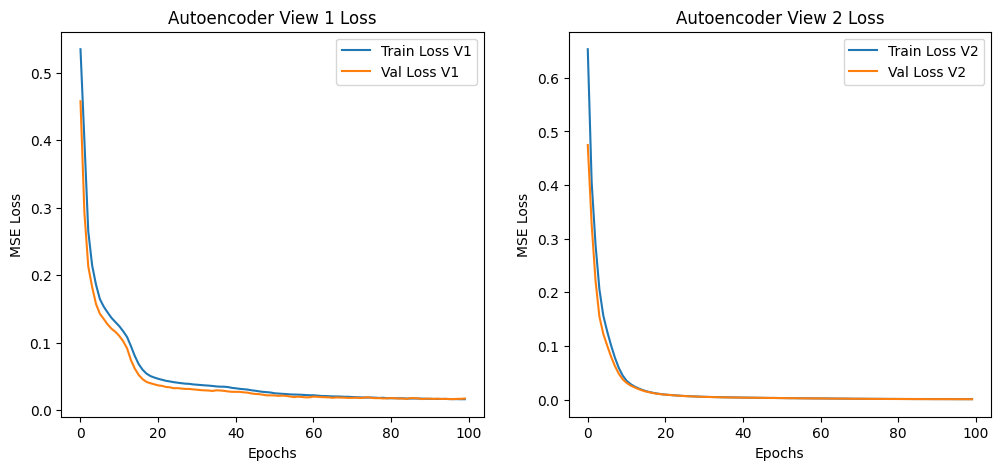

In [ ]:
# Cell 4: Train the two autoencoders.
epochs = 100
batch_size = 32

# Train view 1 autoencoder
history_v1 = autoencoder_v1.fit(X, X,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_split=0.1,
                                verbose=1)

# Train view 2 autoencoder
history_v2 = autoencoder_v2.fit(X, X,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_split=0.1,
                                verbose=1)

# (Optional) Plot training loss for view 1 and view 2
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_v1.history['loss'], label='Train Loss V1')
plt.plot(history_v1.history['val_loss'], label='Val Loss V1')
plt.title("Autoencoder View 1 Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_v2.history['loss'], label='Train Loss V2')
plt.plot(history_v2.history['val_loss'], label='Val Loss V2')
plt.title("Autoencoder View 2 Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [ ]:
# Cell 5: Extract latent embeddings from both autoencoders
encoder_v1 = Model(inputs=input_layer_v1, outputs=latent_v1, name='encoder_v1')
encoder_v2 = Model(inputs=input_layer_v2, outputs=latent_v2, name='encoder_v2')

latent_embeddings_v1 = encoder_v1.predict(X)
latent_embeddings_v2 = encoder_v2.predict(X)

print("Latent embedding shape from view 1:", latent_embeddings_v1.shape)
print("Latent embedding shape from view 2:", latent_embeddings_v2.shape)

# Fuse the two embeddings by taking the average (element-wise)
fused_embedding = (latent_embeddings_v1 + latent_embeddings_v2) / 2.0
print("Fused embedding shape:", fused_embedding.shape)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Latent embedding shape from view 1: (1799, 4)
Latent embedding shape from view 2: (1799, 4)
Fused embedding shape: (1799, 4)


# ***`K-Means`***

In [ ]:
# GridSearch for optimal KMeans parameters on the fused embedding
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

def evaluate_clustering(X_emb, labels):
    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)
    return sil, db, ch

# Define a parameter grid for KMeans while keeping n_clusters=5 constant.
param_grid = {
    'init': ['k-means++', 'random']
}

best_silhouette = -np.inf  # objective: maximize silhouette score
best_params = None
results = []

for init_method in param_grid['init']:
            kmeans_candidate = KMeans(n_clusters=5, init=init_method, random_state=42)
            candidate_labels = kmeans_candidate.fit_predict(fused_embedding)
            sil, db, ch = evaluate_clustering(fused_embedding, candidate_labels)
            results.append({
                'init': init_method,
                'silhouette': sil,
                'davies_bouldin': db,
                'calinski_harabasz': ch
            })
            if sil > best_silhouette:
                best_silhouette = sil
                best_params = {
                    'init': init_method
                     }

results_df = pd.DataFrame(results)
print("Grid Search results for KMeans parameters:")
print(results_df)
print("\nOptimal parameters based on silhouette score:")
print(best_params)


Grid Search results for KMeans parameters:
        init  silhouette  davies_bouldin  calinski_harabasz
0  k-means++    0.442716        0.768705        3379.112793
1     random    0.442716        0.768705        3379.112793

Optimal parameters based on silhouette score:
{'init': 'k-means++'}


In [ ]:
# Use the best parameters from grid search for final clustering
optimal_kmeans = KMeans(n_clusters=5, init=best_params['init'], random_state=42)
final_cluster_labels = optimal_kmeans.fit_predict(fused_embedding)

# Evaluate clustering metrics on the fused embedding
sil, db, ch = evaluate_clustering(fused_embedding, final_cluster_labels)
print(f"Final Clustering Metrics:")
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.4f}")


Final Clustering Metrics:
Silhouette Score: 0.4427
Davies-Bouldin Score: 0.7687
Calinski-Harabasz Score: 3379.1128


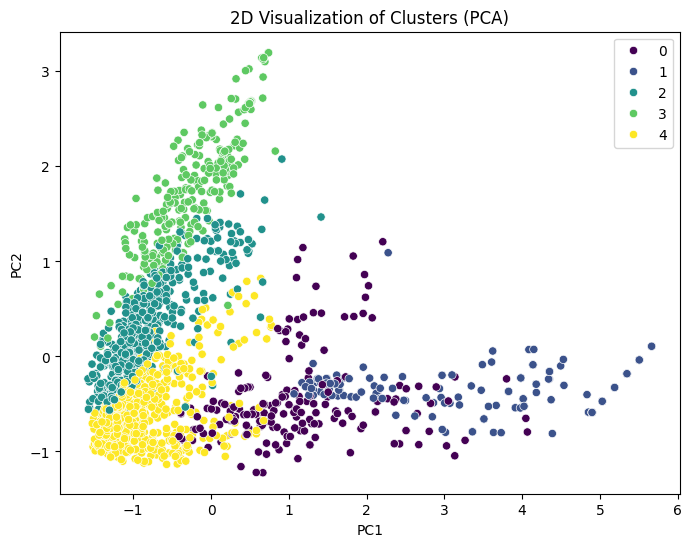

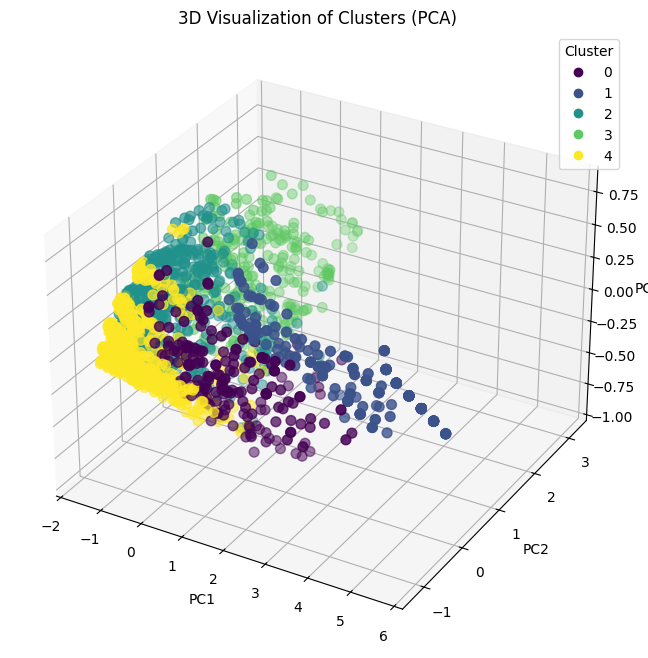

In [ ]:
# Cell 7: Visualize the clustering result using PCA (2D and 3D)
from sklearn.decomposition import PCA

# 2D Visualization
pca_2d = PCA(n_components=2)
embedding_2d = pca_2d.fit_transform(fused_embedding)
plt.figure(figsize=(8,6))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=cluster_labels, palette='viridis', legend='full')
plt.title("2D Visualization of Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 3D Visualization
pca_3d = PCA(n_components=3)
embedding_3d = pca_3d.fit_transform(fused_embedding)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(embedding_3d[:,0], embedding_3d[:,1], embedding_3d[:,2],
                     c=cluster_labels, cmap='viridis', s=50)
ax.set_title("3D Visualization of Clusters (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


# ***`Agglomerative`***

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

def evaluate_clustering(X_emb, labels):
    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)
    return sil, db, ch

# Define a parameter grid for AgglomerativeClustering
param_grid = {
    'linkage': ['ward', 'complete', 'average', 'single']
}

best_silhouette = -np.inf   # We aim to maximize the Silhouette score
best_params = None
results = []

for linkage in param_grid['linkage']:
    try:
        # Note: 'ward' linkage only works with Euclidean distance.
        agglo = AgglomerativeClustering(n_clusters=3, linkage=linkage)
        labels = agglo.fit_predict(fused_embedding)  # fused_embedding: your multi-view fused latent representation
        sil, db, ch = evaluate_clustering(fused_embedding, labels)
        results.append({
            'linkage': linkage,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })
        if sil > best_silhouette:
            best_silhouette = sil
            best_params = {'linkage': linkage}
    except Exception as e:
        print("Error with linkage:", linkage, ":", e)

results_df = pd.DataFrame(results)
print("Grid Search results for Agglomerative Clustering (n_clusters=3):")
print(results_df)
print("\nOptimal parameters based on highest Silhouette score:")
print(best_params)


Grid Search results for Agglomerative Clustering (n_clusters=3):
    linkage  silhouette  davies_bouldin  calinski_harabasz
0      ward    0.391143        0.875657        2058.383301
1  complete    0.426322        0.793794        2203.606689
2   average    0.448960        0.776381        2001.653076
3    single   -0.139315        1.441980           3.749732

Optimal parameters based on highest Silhouette score:
{'linkage': 'average'}


# ***`Gaussian Mixture Model`***

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

def evaluate_clustering(X_emb, labels):
    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)
    return sil, db, ch

# Define grid of parameters for GMM with n_components fixed at 3
param_grid = {
    'covariance_type': ['full', 'diag', 'spherical', 'tied'],
}

best_silhouette = -np.inf  # We aim to maximize the Silhouette score
best_params = None
results = []

for cov_type in param_grid['covariance_type']:
        gmm = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=42)
        # Fit GMM to fused_embedding (assumed to be already computed)
        gmm.fit(fused_embedding)
        labels = gmm.predict(fused_embedding)
        sil, db, ch = evaluate_clustering(fused_embedding, labels)
        results.append({
            'covariance_type': cov_type,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })
        if sil > best_silhouette:
            best_silhouette = sil
            best_params = {'covariance_type': cov_type, 'init_params': init_param}

results_df = pd.DataFrame(results)
print("Grid Search results for GMM with n_components=3:")
print(results_df)
print("\nOptimal parameters based on highest Silhouette score:")
print(best_params)


Grid Search results for GMM with n_components=3:
  covariance_type  silhouette  davies_bouldin  calinski_harabasz
0            full    0.245040        0.963007        1026.035522
1            diag    0.390678        0.874957        1406.128784
2       spherical    0.470232        0.757223        2073.656982
3            tied    0.423357        0.767260        2195.325928

Optimal parameters based on highest Silhouette score:
{'covariance_type': 'spherical', 'init_params': 'random'}
